# Not Using Pauli Frame Update

In [1]:
from qiskit import __version__
print(__version__)

2.1.1


In [2]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace, DensityMatrix, Pauli
from qiskit.quantum_info.operators import Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.controlflow import IfElseOp
from qiskit.circuit.library import XGate, ZGate
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import List

In [3]:
import sys
sys.path.append('Steane')
import importlib
import steane_ec_decoder
importlib.reload(steane_ec_decoder)
from steane_ec_decoder import lookup

In [4]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
amp_0 = np.cos(theta/2)
amp_1 = np.sin(theta/2)

In [5]:
# Custom Hadamard 
h_sub = QuantumCircuit(1, name='H_custom')
h_sub.h(0)
H_custom = h_sub.to_gate()

# Custom CNOT 
cx_sub = QuantumCircuit(2, name='CX_custom')
cx_sub.cx(0, 1)
CX_custom = cx_sub.to_gate()

# Custom RY
ry_sub = QuantumCircuit(1, name='RY_custom')
ry_sub.ry(theta, 0)
RY_custom = ry_sub.to_gate()

# Custom -RY
neg_ry_sub = QuantumCircuit(1, name='N_RY_custom')
neg_ry_sub.ry(-theta, 0)
N_RY_custom = neg_ry_sub.to_gate()

# Function for Encoding

In [5]:
def init_encoding(qc: QuantumCircuit, first_qubit: int):
    qc.ry(theta, 0)
    for i in range(4, 7):
        qc.h(first_qubit+i)
    qc.cx(first_qubit, first_qubit+1)
    qc.cx(first_qubit, first_qubit+2)
    qc.cx(first_qubit+6, first_qubit)
    qc.cx(first_qubit+6, first_qubit+1)
    qc.cx(first_qubit+5, first_qubit)
    qc.cx(first_qubit+6, first_qubit+3)
    qc.cx(first_qubit+5, first_qubit+2)
    qc.cx(first_qubit+4, first_qubit+1)
    qc.cx(first_qubit+5, first_qubit+3)
    qc.cx(first_qubit+4, first_qubit+2)
    qc.cx(first_qubit+4, first_qubit+3)
    return

def decoding(qc: QuantumCircuit, first_qubit: int):
    qc.cx(first_qubit+4, first_qubit+3)
    qc.cx(first_qubit+4, first_qubit+2)
    qc.cx(first_qubit+5, first_qubit+3)
    qc.cx(first_qubit+4, first_qubit+1)
    qc.cx(first_qubit+5, first_qubit+2)
    qc.cx(first_qubit+6, first_qubit+3)
    qc.cx(first_qubit+5, first_qubit)
    qc.cx(first_qubit+6, first_qubit+1)
    qc.cx(first_qubit+6, first_qubit)
    qc.cx(first_qubit, first_qubit+2)
    qc.cx(first_qubit, first_qubit+1)
    for i in range(4, 7):
        qc.h(first_qubit+i)
    qc.ry(-theta, 0)
    return

In [6]:
def perfect_encoding(qc: QuantumCircuit, first_qubit: int):
    qc.append(RY_custom, [first_qubit])
    for i in range(4, 7):
        qc.append(H_custom, [first_qubit+i])
    qc.append(CX_custom, [first_qubit, first_qubit+1])
    qc.append(CX_custom, [first_qubit, first_qubit+2])
    qc.append(CX_custom, [first_qubit+6, first_qubit])
    qc.append(CX_custom, [first_qubit+6, first_qubit+1])
    qc.append(CX_custom, [first_qubit+5, first_qubit])
    qc.append(CX_custom, [first_qubit+6, first_qubit+3])
    qc.append(CX_custom, [first_qubit+5, first_qubit+2])
    qc.append(CX_custom, [first_qubit+4, first_qubit+1])
    qc.append(CX_custom, [first_qubit+5, first_qubit+3])
    qc.append(CX_custom, [first_qubit+4, first_qubit+2])
    qc.append(CX_custom, [first_qubit+4, first_qubit+3])
    return
    
def inverse_perfect_encoding(qc: QuantumCircuit, first_qubit: int):
    qc.append(CX_custom, [first_qubit+4, first_qubit+3])
    qc.append(CX_custom, [first_qubit+4, first_qubit+2])
    qc.append(CX_custom, [first_qubit+5, first_qubit+3])
    qc.append(CX_custom, [first_qubit+4, first_qubit+1])
    qc.append(CX_custom, [first_qubit+5, first_qubit+2])
    qc.append(CX_custom, [first_qubit+6, first_qubit+3])
    qc.append(CX_custom, [first_qubit+5, first_qubit])
    qc.append(CX_custom, [first_qubit+6, first_qubit+1])
    qc.append(CX_custom, [first_qubit+6, first_qubit])
    qc.append(CX_custom, [first_qubit, first_qubit+2])
    qc.append(CX_custom, [first_qubit, first_qubit+1])
    for i in range(4, 7):
        qc.append(H_custom, [first_qubit+i])
    qc.append(N_RY_custom, [first_qubit])
    return

# Simulations with Fidelity

In [8]:
one_qubit_noise = []
for i in range(1, 7):
    one_qubit_noise.append(np.round((0.00002*i), 5)) # Quantinuum 1Q Gate
    
meas_noise = []
for i in range(1, 7):
    meas_noise.append(np.round((0.0015*i), 4)) # Quantinuum SPAM 
    
two_qubit_noise = []
for i in range(1, 7):
    two_qubit_noise.append(np.round((0.0016*i), 4)) # Quantinuum 2Q Gate

In [16]:
ideal = QuantumCircuit(8)
ideal = Statevector(ideal)

Text(0, 0.5, 'Infidelity')

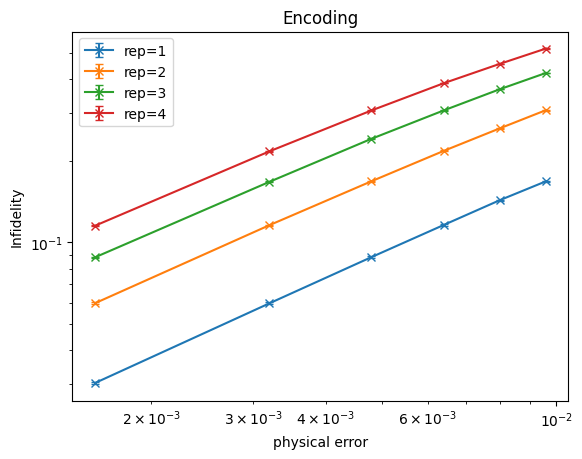

In [27]:
all_infidelity = []
all_unc = []
shots = 1_000_000
for rep in range(1, 5):
    infidelity_list = []
    unc_list = []
    for noise in range(len(one_qubit_noise)):
        #################################################################################
        # Error model
        noise_model = NoiseModel()
        
        #noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['id'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['h'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['ry'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_noise[noise],2), ['cx'])

        # chance of flipping 0 <-> 1
        readout_err = ReadoutError([[1-meas_noise[noise], meas_noise[noise]],  # P(measured 0 | actual 0), P(1 | 0)
                                    [meas_noise[noise], 1-meas_noise[noise]]]) # P(0 | 1), P(1 | 1)
        
        # Apply to all qubits being measured
        """
        noise_model.add_readout_error(readout_err, [0]) 
        noise_model.add_readout_error(readout_err, [1])
        noise_model.add_readout_error(readout_err, [2])
        noise_model.add_readout_error(readout_err, [3])
        noise_model.add_readout_error(readout_err, [4])
        noise_model.add_readout_error(readout_err, [5])
        noise_model.add_readout_error(readout_err, [6])
        """
        #################################################################################
        qc = QuantumCircuit(8)
        c_fin = ClassicalRegister(1)
        qc.add_register(c_fin)
        for i in range(rep):
            init_encoding(qc, first_qubit=0)
            decoding(qc, 0)
        qc.measure([7], c_fin)
        #################################################################################
        qc.save_statevector(label='state_post', pershot=True, conditional=True)
        backend = AerSimulator(noise_model=noise_model)
        transpiled = transpile(qc, backend, optimization_level=0)
        job = backend.run(transpiled, shots=shots, memory=True)
        result = job.result()
        memory = result.get_memory()
        #################################################################################
        data = result.data(0)
        mem_list = data["memory"] # in hex
        state_post = data["state_post"]
        mem_to_sv = [] # hex: statevector
        seen = defaultdict(int)
        for mem in mem_list:
            k = seen[mem]
            mem_to_sv.append({mem: state_post[mem][k]})
            seen[mem] += 1
            
        sumfid = 0
        erase = 0
        
        for i, shot in enumerate(mem_to_sv):
            split = memory[i]
            split = split.split()
            encoding = split[-1]
            if (encoding == "0"):
                sv = shot[next(iter(shot))]
                #sv = partial_trace(sv, [7])
                sumfid += state_fidelity(sv, ideal)
            else:
                erase += 1
        infidelity = 1 - (sumfid/(shots-erase))
        infidelity_list.append(infidelity)
        unc_list.append(1.96 * np.sqrt( (infidelity * (1 - infidelity) / (shots-erase) )))
    plt.errorbar(
        two_qubit_noise,
        infidelity_list,
        yerr=unc_list,
        fmt='-x',
        label=f'rep={rep}',
        capsize=3  # little horizontal caps on the error bars
    )
    all_infidelity.append(infidelity_list)
    all_unc.append(unc_list)

plt.title('Encoding')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('physical error')
plt.ylabel('Infidelity')

In [ ]:
# all_error.shape == (num_reps, num_noises)
# uncertainties.shape == (num_reps, num_noises)
all_infidelity = np.array(all_infidelity)
all_unc = np.array(all_unc)
num_reps, num_noises = all_infidelity.shape

x = range(1, 5)

for k in range(num_noises):
    plt.errorbar(
        x,
        all_infidelity[:, k],
        yerr=all_unc[:, k],
        fmt='-x',
        capsize=3,
        label=f'noise={two_qubit_noise[k]}'
    )

plt.legend()
plt.xlabel('rep')
plt.ylabel('Infidelity')
plt.show()

In [ ]:
x = np.array(list(range(1, 5)))   
slopes = []

for k, noise in enumerate(two_qubit_noise):
    y = all_infidelity[:, k]               # error vs rep for this noise
    m, b = np.polyfit(x, y, 1)
    slopes.append(m)
    print(f"noise={noise:0.4f} → slope = {m:.4f} per rep")

Text(0, 0.5, 'logical error')

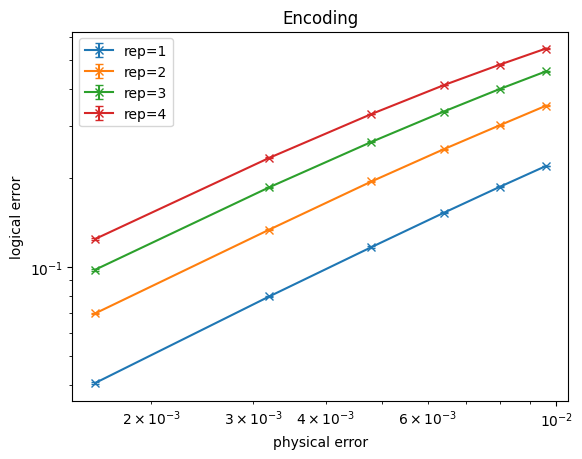

In [31]:
all_logical_error = []
all_unc = []
shots = 1_000_000
for rep in range(1, 5):
    logical_error_list = []
    unc_list = []
    for noise in range(len(one_qubit_noise)):
        sum = 0
        erase = 0
        #################################################################################
        # Error model
        noise_model = NoiseModel()
        
        #noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['id'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['h'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['ry'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_noise[noise],2), ['cx'])

        # chance of flipping 0 <-> 1
        readout_err = ReadoutError([[1-meas_noise[noise], meas_noise[noise]],  # P(measured 0 | actual 0), P(1 | 0)
                                    [meas_noise[noise], 1-meas_noise[noise]]]) # P(0 | 1), P(1 | 1)
        
        # Apply to all qubits being measured
        
        noise_model.add_readout_error(readout_err, [0]) 
        noise_model.add_readout_error(readout_err, [1])
        noise_model.add_readout_error(readout_err, [2])
        noise_model.add_readout_error(readout_err, [3])
        noise_model.add_readout_error(readout_err, [4])
        noise_model.add_readout_error(readout_err, [5])
        noise_model.add_readout_error(readout_err, [6])
        
        #################################################################################
        qc = QuantumCircuit(8)
        c_fin = ClassicalRegister(7)
        qc.add_register(c_fin)
        for i in range(rep):
            init_encoding(qc, first_qubit=0)
            decoding(qc, 0)
        qc.measure([0, 1, 2, 3, 4, 5, 6], c_fin)
        #################################################################################
        #qc.save_statevector(label='state_post', pershot=True, conditional=True)
        backend = AerSimulator(noise_model=noise_model)
        transpiled = transpile(qc, backend, optimization_level=0)
        job = backend.run(transpiled, shots=shots, memory=True)
        result = job.result()
        memory = result.get_memory()
        #################################################################################
        #res_statevectors = result.data()['state_post']
        for shot in range(shots):
            split = memory[shot].split()
            if (split[-1] == "1"):
                    erase += 1
            elif (split[0] == "0000000"):
                    sum += 1
        error = 1 - (sum/(shots-erase))
        logical_error_list.append(error)
        unc_list.append(1.96 * np.sqrt( (error * (1 - error) / (shots-erase) )))

    all_logical_error.append(logical_error_list)
    all_unc.append(unc_list)
    plt.errorbar(
        two_qubit_noise,
        logical_error_list,
        yerr=unc_list,
        fmt='-x',
        label=f'rep={rep}',
        capsize=3  # little horizontal caps on the error bars
    )
    
plt.title('Encoding')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('physical error')
plt.ylabel('logical error')

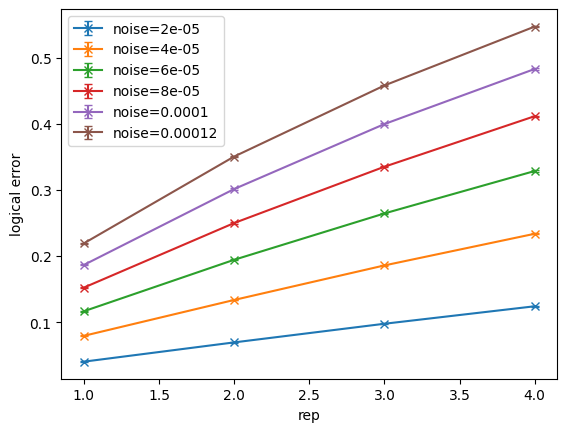

In [32]:
# all_error.shape == (num_reps, num_noises)
# uncertainties.shape == (num_reps, num_noises)
all_error = np.array(all_logical_error)
all_unc = np.array(all_unc)
num_reps, num_noises = all_error.shape

x = range(1, 5)

for k in range(num_noises):
    plt.errorbar(
        x,
        all_error[:, k],
        yerr=all_unc[:, k],
        fmt='-x',
        capsize=3,
        label=f'noise={one_qubit_noise[k]}'
    )

plt.legend()
plt.xlabel('rep')
plt.ylabel('logical error')
plt.show()

In [33]:
slopes = []

for k, noise in enumerate(one_qubit_noise):
    y = all_error[:, k]               # error vs rep for this noise
    m, b = np.polyfit(x, y, 1)
    slopes.append(m)
    print(f"noise={noise:0.6f} → slope = {m:.6f} per rep")

noise=0.000020 → slope = 0.027926 per rep
noise=0.000040 → slope = 0.051479 per rep
noise=0.000060 → slope = 0.070576 per rep
noise=0.000080 → slope = 0.086199 per rep
noise=0.000100 → slope = 0.098649 per rep
noise=0.000120 → slope = 0.109000 per rep


# Each rep is encoding + inverse encoding, without EC

In [7]:
def decoder(memory: List[str]):
    shots = len(memory)
    error = 0
    
    for i in range(shots):
        stab1 = (int(memory[i][0]) + int(memory[i][2]) + int(memory[i][4]) + int(memory[i][6])) % 2
        stab2 = (int(memory[i][3]) + int(memory[i][4]) + int(memory[i][5]) + int(memory[i][6])) % 2
        stab3 = (int(memory[i][1]) + int(memory[i][2]) + int(memory[i][5]) + int(memory[i][6])) % 2
        checks = [stab1, stab2, stab3]
        op = (int(memory[i][4]) + int(memory[i][5]) + int(memory[i][6])) % 2
        
        if (checks[1] == 1):
            pass
        elif (checks[0] == 1 or checks[2] == 1):
            op = (op + 1) % 2
        
        if (op == 1):
            error += 1
    
    err_rate = error/shots
    unc = 1.96 * np.sqrt( (err_rate * (1 - err_rate) / shots ))
    return err_rate, unc

In [8]:
one_qubit_noise = []
for i in range(1, 7):
    one_qubit_noise.append(np.round((0.00002*i), 5)) # Quantinuum 1Q Gate
    
meas_noise = []
for i in range(1, 7):
    meas_noise.append(np.round((0.0015*i), 4)) # Quantinuum SPAM 
    
two_qubit_noise = []
for i in range(1, 7):
    two_qubit_noise.append(np.round((0.0016*i), 4)) # Quantinuum 2Q Gate

Text(0, 0.5, 'logical error')

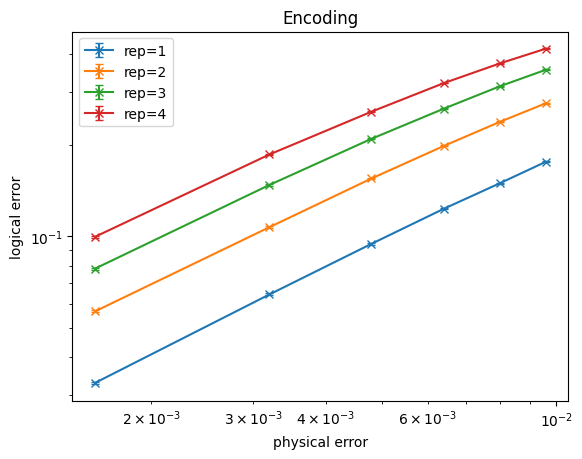

In [9]:
all_error = []
all_unc = []
for rep in range(1, 5):
    logical_error_rates = []
    unc = []
    for noise in range(len(one_qubit_noise)):
        #################################################################################
        # Error model
        noise_model = NoiseModel()
        
        #noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['id'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['h'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['ry'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_noise[noise],2), ['cx'])

        # chance of flipping 0 <-> 1
        readout_err = ReadoutError([[1-meas_noise[noise], meas_noise[noise]],  # P(measured 0 | actual 0), P(1 | 0)
                                    [meas_noise[noise], 1-meas_noise[noise]]]) # P(0 | 1), P(1 | 1)

        # Apply to all qubits being measured
        noise_model.add_readout_error(readout_err, [0]) 
        noise_model.add_readout_error(readout_err, [1])
        noise_model.add_readout_error(readout_err, [2])
        noise_model.add_readout_error(readout_err, [3])
        noise_model.add_readout_error(readout_err, [4])
        noise_model.add_readout_error(readout_err, [5])
        noise_model.add_readout_error(readout_err, [6])
        #################################################################################
        qc = QuantumCircuit(7)
        c = ClassicalRegister(7, "c")
        qc.add_register(c)

        for i in range(rep):
            init_encoding(qc, 0)
            decoding(qc, 0)
        qc.measure([0, 1, 2, 3, 4, 5, 6], c)
        #################################################################################
        backend = AerSimulator(noise_model=noise_model)
        transpiled = transpile(qc, backend, optimization_level=0)
        job = backend.run(transpiled, shots=1_000_000, memory=True)
        result = job.result()
        memory = result.get_memory()
        #################################################################################
        err_rate, u = decoder(memory)
        logical_error_rates.append(err_rate)
        unc.append(u)
    
    plt.errorbar(
        two_qubit_noise,
        logical_error_rates,
        yerr=unc,
        fmt='-x',
        label=f'rep={rep}',
        capsize=3  # little horizontal caps on the error bars
    )
    all_error.append(logical_error_rates)
    all_unc.append(unc)
    
plt.title('Encoding')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('physical error')
plt.ylabel('logical error')

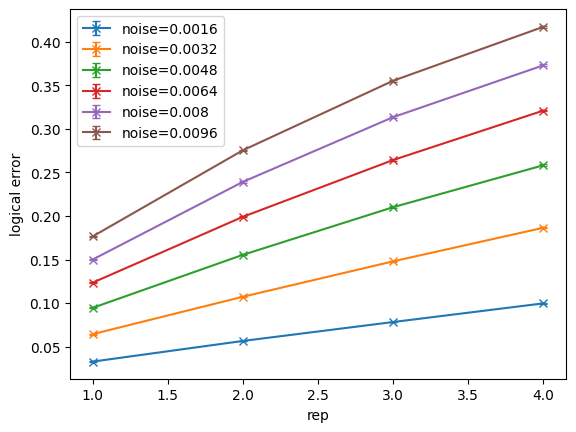

In [12]:
# all_error.shape == (num_reps, num_noises)
# uncertainties.shape == (num_reps, num_noises)
all_error = np.array(all_error)
all_unc = np.array(all_unc)
num_reps, num_noises = all_error.shape

x = range(1, 5)

for k in range(num_noises):
    plt.errorbar(
        x,
        all_error[:, k],
        yerr=all_unc[:, k],
        fmt='-x',
        capsize=3,
        label=f'noise={two_qubit_noise[k]}'
    )

plt.legend()
plt.xlabel('rep')
plt.ylabel('logical error')
plt.show()

In [13]:
x = np.array(list(range(1, 5)))   
slopes = []

for k, noise in enumerate(two_qubit_noise):
    y = all_error[:, k]               # error vs rep for this noise
    m, b = np.polyfit(x, y, 1)
    slopes.append(m)
    print(f"noise={noise:0.4f} → slope = {m:.4f} per rep")

noise=0.0016 → slope = 0.0222 per rep
noise=0.0032 → slope = 0.0407 per rep
noise=0.0048 → slope = 0.0546 per rep
noise=0.0064 → slope = 0.0658 per rep
noise=0.0080 → slope = 0.0743 per rep
noise=0.0096 → slope = 0.0802 per rep


In [28]:
x = np.array(list(range(1, 5)), dtype=float)
slopes, slope_errs = [], []

for k, noise in enumerate(two_qubit_noise):
    y = all_error[:, k]          # logical error vs rep
    sigma = all_unc[:, k]        # 1σ uncertainty for each point
    
    # Weighted least squares: weights are 1/σ
    coeffs, cov = np.polyfit(x, y, deg=1, w=1/np.asarray(sigma), cov=True)
    m, b = coeffs                 # y = m x + b
    m_err = np.sqrt(cov[0, 0])    # standard error of slope

    slopes.append(m)
    slope_errs.append(m_err)
    print(f"noise={noise:0.6f} → slope = {m:.6g} ± {m_err:.2g} per rep")

noise=0.001600 → slope = 0.0224013 ± 0.00039 per rep
noise=0.003200 → slope = 0.0409798 ± 0.00068 per rep
noise=0.004800 → slope = 0.0552487 ± 0.0019 per rep
noise=0.006400 → slope = 0.0666581 ± 0.0029 per rep
noise=0.008000 → slope = 0.0755053 ± 0.0046 per rep
noise=0.009600 → slope = 0.0814421 ± 0.0057 per rep


In [29]:
logical_error_rate = []
logical_error_rate_unc = []
x_axis = []
for i in range(4):
    logical_error_rate.append(slopes[i])
    logical_error_rate_unc.append(slope_errs[i])
    x_axis.append(two_qubit_noise[i])
print(logical_error_rate)
print(slope_errs)
print(x_axis)

[np.float64(0.0224012939589887), np.float64(0.04097983764378561), np.float64(0.05524871953226997), np.float64(0.06665805154057787)]
[np.float64(0.0003946925167258366), np.float64(0.0006766590587916328), np.float64(0.001949811549737372), np.float64(0.0029235952436606843), np.float64(0.0045634672036219725), np.float64(0.005701220971160908)]
[np.float64(0.0016), np.float64(0.0032), np.float64(0.0048), np.float64(0.0064)]


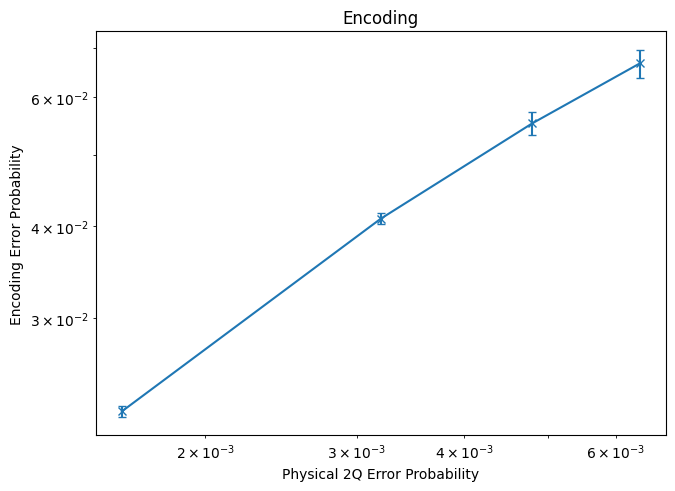

In [30]:
plt.errorbar(
    x_axis,
    logical_error_rate,
    yerr=logical_error_rate_unc,
    fmt='-x',
    capsize=3
)

plt.title('Encoding')
plt.tight_layout()
plt.xlabel('Physical 2Q Error Probability')
plt.ylabel('Encoding Error Probability')
plt.xscale('log')
plt.yscale('log')
plt.show()